In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

In [139]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [141]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# Task 1.1

In [142]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

story_table = (
    df.groupby("Revenue")[story_features]
      .mean()
      .T
)

story_table.columns = ["No purchase", "Purchase"]

story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


# Task 1.2

In [143]:
df["BrowserGroup"] = np.where(
    df["Browser"] == 13,
    "Browser 13",
    "Other browsers"
)

print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [144]:
story_table = (
    df.groupby("BrowserGroup")
      .mean(numeric_only=True)
      .T
)

story_table.columns = ["Other Browsers", "Browser 13"]

story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


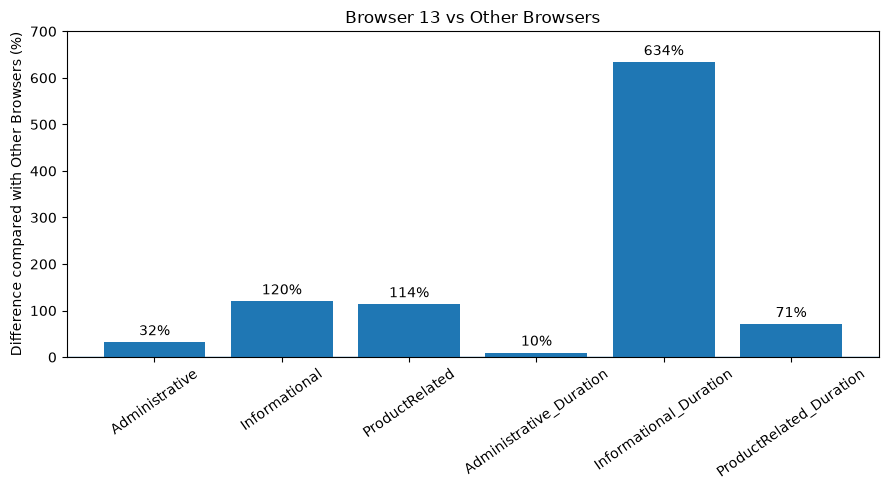

In [145]:
import matplotlib.pyplot as plt
import numpy as np

features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration"
]

other = story_table.loc[features, "Other Browsers"]
browser13 = story_table.loc[features, "Browser 13"]

# Percentage difference compared with Other Browsers
percentage_difference = ((browser13 - other) / other) * 100

# Create chart
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    features,
    percentage_difference
)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Difference compared with Other Browsers (%)")
ax.set_title("Browser 13 vs Other Browsers")
ax.tick_params(axis="x", rotation=35)

# Add values above/below bars
for bar, value in zip(bars, percentage_difference):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (15 if value >= 0 else -35),
        f"{value:.0f}%",
        ha="center"
    )

ax.set_ylim(0, 700)

plt.tight_layout()
plt.show()

# Task 2: Normalization
According to the documentation, before the clustering analysis, the data frame needs to be preprocessed. Numerical variables will be standardized using StandardScaler, while nominal variables will be one-hot encoded. Boolean variables will be turned into 0/1 values.

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('online_shoppers_intention.csv')

# StandardScaler is used instead of Min-Max normalization because
# StandardScaler does not map the data directly to a fixed range
# and is commonly used to put numerical features on a comparable scale.
def standardscaler_normalization(dataframe, column: str):
    mean = dataframe[column].mean()
    std = dataframe[column].std(ddof=0)
    return [
        (val - mean) / std
        for val in dataframe[column]
    ]

columns_to_scale = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

for column in columns_to_scale:
    df[column] = standardscaler_normalization(df, column)

# One hot encode for nominal variables
def one_hot_encode(dataframe, column):
    categories = dataframe[column].unique()

    for category in categories:
        dataframe[f"{column}_{category}"] = (
            dataframe[column] == category
        ).astype(int)

    return dataframe.drop(columns=[column])

columns_to_one_hot_encode = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

for column in columns_to_one_hot_encode:
    df = one_hot_encode(df, column)

# Encode true/false into 0/1 features
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

# There are no missing values, so no rows need to be removed or imputed.

# Functions: 
- sample_data
- run_affinity_propagation
- run_dbscan
- run_birch
- filter_clusters
- plot_three_clusters

In [374]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import AffinityPropagation
from sklearn.decomposition import PCA


def sample_data(dataframe, sample_size=500, random_state=42):
    """
    Take a random sample of the dataframe.
    """
    return dataframe.sample(
        n=min(sample_size, len(dataframe)),
        random_state=random_state
    )


def run_affinity_propagation(
    dataframe,
    damping=0.9,
    max_iter=100,
    convergence_iter=10,
    random_state=42
):
    """
    Run Affinity Propagation clustering.

    Returns:
        model: fitted AffinityPropagation model
        labels: cluster label for each observation
    """

    model = AffinityPropagation(
        damping=damping,
        max_iter=max_iter,
        convergence_iter=convergence_iter,
        random_state=random_state
    )

    labels = model.fit_predict(dataframe)

    return model, labels

from sklearn.cluster import DBSCAN

def run_dbscan(
    dataframe,
    eps=0.5,
    min_samples=5
):
    """
    Run DBSCAN clustering.

    Returns:
        model: fitted DBSCAN model
        labels: cluster label for each observation
    """

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(dataframe)

    return model, labels

from sklearn.cluster import Birch

def run_birch(
    dataframe,
    n_clusters=5
):
    """
    Run BIRCH clustering.

    Returns:
        model: fitted Birch model
        labels: cluster label for each observation
    """

    model = Birch(
        n_clusters=n_clusters
    )

    labels = model.fit_predict(dataframe)

    return model, labels


def filter_clusters(dataframe, labels, min_cluster_size=15):
    """
    Keep only clusters containing more than min_cluster_size observations.
    DBSCAN noise (-1) is always removed.

    Returns:
        filtered_dataframe
        filtered_labels
        cluster_sizes
        valid_clusters
    """

    # Count observations in each cluster
    cluster_sizes = pd.Series(labels).value_counts()

    # Remove DBSCAN noise from valid clusters
    valid_clusters = cluster_sizes[
        (cluster_sizes > min_cluster_size) &
        (cluster_sizes.index != -1)
    ].index

    # Create mask using the dataframe index
    mask = pd.Series(
        labels,
        index=dataframe.index
    ).isin(valid_clusters)

    # Filter both data AND labels using the exact same mask
    filtered_dataframe = dataframe.loc[mask]

    filtered_labels = labels[mask.values]

    return (
        filtered_dataframe,
        filtered_labels,
        cluster_sizes,
        valid_clusters
    )



def plot_three_clusters(
    X_pca,
    labels_ap,
    labels_dbscan,
    labels_birch,
    explained_variance_ratio
):
    pc1_ratio = explained_variance_ratio[0] * 100
    pc2_ratio = explained_variance_ratio[1] * 100

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5)
    )

    results = [
        (labels_ap, "Affinity Propagation"),
        (labels_dbscan, "DBSCAN"),
        (labels_birch, "BIRCH")
    ]

    for ax, (labels, title) in zip(axes, results):

        unique_labels = sorted(set(labels))
        n_clusters = len(unique_labels)

        cmap = plt.get_cmap(
            "tab10",
            n_clusters
        )

        label_map = {
            label: i
            for i, label in enumerate(unique_labels)
        }

        color_values = [
            label_map[label]
            for label in labels
        ]

        scatter = ax.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            c=color_values,
            cmap=cmap,
            vmin=-0.5,
            vmax=n_clusters - 0.5,
            alpha=0.6
        )

        ax.set_xlabel(
            f"PC1 ({pc1_ratio:.1f}%)"
        )

        ax.set_ylabel(
            f"PC2 ({pc2_ratio:.1f}%)"
        )

        ax.set_title(title)

        colorbar = fig.colorbar(
            scatter,
            ax=ax,
            ticks=range(n_clusters)
        )

        colorbar.set_label("Cluster")
        colorbar.set_ticklabels(unique_labels)

    plt.tight_layout()
    plt.show()

# Task 3 
# Affinity Propagation Clustering, DBSCAN Clustering, BIRCH Clustering

Original dimensions: 75
PCA dimensions: 5

Affinity Propagation - clusters after filtering:
0    481
1     18
Name: count, dtype: int64
Number of clusters: 2

DBSCAN - clusters after filtering:
0    245
1     36
Name: count, dtype: int64
Number of clusters: 2

BIRCH - clusters after filtering:
0    389
1     36
3     71
Name: count, dtype: int64
Number of clusters: 3


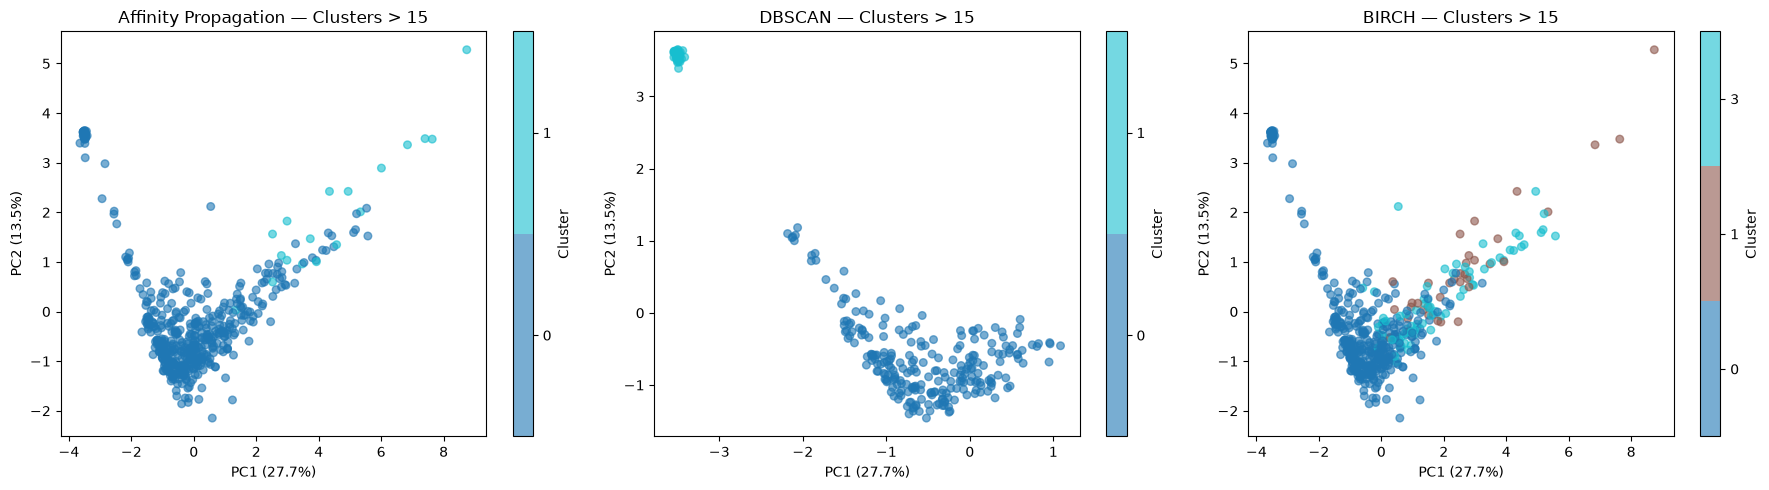

In [384]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# 1. Sample data
df_sample = sample_data(
    df,
    sample_size=500,
    random_state=42
)

# 2. PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_sample)

print("Original dimensions:", df_sample.shape[1])
print("PCA dimensions:", X_pca.shape[1])


# Convert PCA results to DataFrame
X_pca_df = pd.DataFrame(
    X_pca,
    index=df_sample.index
)


# 3. Run the three clustering algorithms

af, labels_ap = run_affinity_propagation(
    X_pca,
    damping=0.9,
    max_iter=100,
    convergence_iter=10,
    random_state=42
)

dbscan, labels_dbscan = run_dbscan(
    X_pca,
    eps=0.5,
    min_samples=5
)

brc, labels_birch = run_birch(
    X_pca,
    n_clusters=4
)


# 4. Store the results
algorithms = [
    ("Affinity Propagation", labels_ap),
    ("DBSCAN", labels_dbscan),
    ("BIRCH", labels_birch)
]


# 5. Filter small clusters
results = []

for name, labels in algorithms:

    X_filtered, labels_filtered, cluster_sizes, valid_clusters = (
        filter_clusters(
            X_pca_df,
            labels,
            min_cluster_size=15
        )
    )

    print(f"\n{name} - clusters after filtering:")
    print(
        pd.Series(labels_filtered)
        .value_counts()
        .sort_index()
    )

    print(
        f"Number of clusters: {len(valid_clusters)}"
    )

    results.append(
        (name, X_filtered.values, labels_filtered)
    )


# 6. Plot
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

pc1_ratio = pca.explained_variance_ratio_[0] * 100
pc2_ratio = pca.explained_variance_ratio_[1] * 100


for ax, (name, X_filtered, labels_filtered) in zip(
    axes,
    results
):

    unique_labels = sorted(set(labels_filtered))
    n_clusters = len(unique_labels)

    cmap = plt.get_cmap("tab10", n_clusters)

    label_map = {
        label: i
        for i, label in enumerate(unique_labels)
    }

    colors = [
        label_map[label]
        for label in labels_filtered
    ]

    scatter = ax.scatter(
        X_filtered[:, 0],
        X_filtered[:, 1],
        c=colors,
        cmap=cmap,
        vmin=-0.5,
        vmax=n_clusters - 0.5,
        alpha=0.6,
        s=30
    )

    ax.set_xlabel(f"PC1 ({pc1_ratio:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_ratio:.1f}%)")
    ax.set_title(f"{name} — Clusters > 15")

    colorbar = fig.colorbar(
        scatter,
        ax=ax,
        ticks=range(n_clusters)
    )

    colorbar.set_label("Cluster")
    colorbar.set_ticklabels(unique_labels)

plt.tight_layout()
plt.show()


The 3 algorithms (Affinity Propagation, DBSCAN and BIRCH) all resulted in very similar PCA plots. For every visualisation, PC1 explains 27.7% of the variance, and PC2 explains 13.5% of the variance. None of the plots have noise (all objects in the plots are clustered).